## 1-Data loading

In [18]:
import h5py
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt

mat_path = "/content/drive/MyDrive/Computational Intelligence/preprocessed_features_for_fis.mat"

with h5py.File(mat_path, "r") as f:
    meanNorm = np.array(f["meanNorm"])
    stdNorm = np.array(f["stdNorm"])
    skewNorm = np.array(f["skewNorm"])
    kurtNorm = np.array(f["kurtNorm"])
    localZNorm = np.array(f["localZNorm"])
    topHatNorm = np.array(f["topHatNorm"])
    priorNorm = np.array(f["priorNorm"])
    regionalPriorNorm = np.array(f["regionalPriorNorm"])
    distanceNorm = np.array(f["distanceNorm"])
    centralityNorm = np.array(f["centralityNorm"])
    brainMasks = np.array(f["brainMasks"])
    wmh = np.array(f["wmh"])

Faetaure dimensions check

In [19]:
print(meanNorm.shape)
print("meanNorm:", meanNorm.shape)
print("wmh:", wmh.shape)
print("brainMasks:", brainMasks.shape)

(611, 186, 151)
meanNorm: (611, 186, 151)
wmh: (611, 186, 151)
brainMasks: (611, 186, 151)


The data have the patient index as first dimension, to be consistent with the MATLAB code I transponse the data

In [20]:
def to_hwn(arr):
    """
    Converts arrays from N x H x W to H x W x N.
    Example: 611 x 186 x 151 -> 186 x 151 x 611
    """
    return np.transpose(arr, (1, 2, 0))


meanNorm = to_hwn(meanNorm)
stdNorm = to_hwn(stdNorm)
skewNorm = to_hwn(skewNorm)
kurtNorm = to_hwn(kurtNorm)
localZNorm = to_hwn(localZNorm)
topHatNorm = to_hwn(topHatNorm)
priorNorm = to_hwn(priorNorm)
regionalPriorNorm = to_hwn(regionalPriorNorm)
distanceNorm = to_hwn(distanceNorm)
centralityNorm = to_hwn(centralityNorm)
brainMasks = to_hwn(brainMasks)
wmh = to_hwn(wmh)

Check if it works

In [21]:
print(meanNorm.shape)
print("meanNorm:", meanNorm.shape)
print("wmh:", wmh.shape)
print("brainMasks:", brainMasks.shape)

(186, 151, 611)
meanNorm: (186, 151, 611)
wmh: (186, 151, 611)
brainMasks: (186, 151, 611)


## 2 - Patient dataframe creation

In the dataframe each row represent one pixel and each column the corresponding feature value. The patient index is kept so that later, in the train and test split, it is prevented the separasion of the same patient features between train and test, which could cause data leakage problems.

In [22]:
def build_patient_dataframe(patient_idx):
    brain = brainMasks[:, :, patient_idx].astype(bool)  # craete the brain mask

    # get the coordinates if the pixels that are inside the brain
    rows, cols = np.where(brain)

    df = pd.DataFrame({
        "patient_id": patient_idx,
        "row": rows,
        "col": cols,

        "mean": meanNorm[:, :, patient_idx][brain],
        "std": stdNorm[:, :, patient_idx][brain],
        "skew": skewNorm[:, :, patient_idx][brain],
        "kurtosis": kurtNorm[:, :, patient_idx][brain],
        "localZ": localZNorm[:, :, patient_idx][brain],
        "topHat": topHatNorm[:, :, patient_idx][brain],
        "prior": priorNorm[:, :, patient_idx][brain],
        "regionalPrior": regionalPriorNorm[:, :, patient_idx][brain],
        "distance": distanceNorm[:, :, patient_idx][brain],
        "WMH": wmh[:, :, patient_idx][brain].astype(int)
    })

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    return df

Create the full dataframe containing all the patients:

In [23]:
n_patients = meanNorm.shape[2]

dfs = []

for patient_idx in range(n_patients):
    dfs.append(build_patient_dataframe(patient_idx))

df = pd.concat(dfs, ignore_index=True)

print(df.head())
print(df.shape)

   patient_id  row  col  mean       std      skew  kurtosis    localZ  \
0           0    4   83   0.0  0.121137  0.999982  0.525219  0.376565   
1           0    4   85   0.0  0.193353  0.752347  0.140586  0.524874   
2           0    4   86   0.0  0.220453  0.765304  0.157394  0.572008   
3           0    4   87   0.0  0.218760  0.764265  0.156856  0.413971   
4           0    5   82   0.0  0.175311  0.844864  0.250955  0.456134   

     topHat  prior  regionalPrior  distance  WMH  
0  0.075704    0.0            0.0  0.968930    0  
1  0.272379    0.0            0.0  0.970753    0  
2  0.311543    0.0            0.0  0.971849    0  
3  0.147956    0.0            0.0  0.973068    0  
4  0.000000    0.0            0.0  0.957225    0  
(12363277, 13)


In [24]:
# Load the CSV that tells which patients were used for the prior
prior_table = pd.read_csv("/content/drive/MyDrive/Computational Intelligence/prior_patients_used.csv")

print(prior_table.head())
print(prior_table.columns)

   patient_index  diagnosis  used_for_prior
0              1          0               1
1              2          0               1
2              3          0               1
3              4          0               1
4              5          0               1
Index(['patient_index', 'diagnosis', 'used_for_prior'], dtype='object')


CSV uses MATLAB patient indices, so they start from 1:

In [25]:
prior_table["patient_id"] = prior_table["patient_index"] - 1

Get the training and testing patients:
  
used_for_prior = 1  -> training set
  
used_for_prior = 0  -> test set

In [26]:
train_patients = prior_table.loc[
    prior_table["used_for_prior"] == 1,
    "patient_id"
].values

test_patients = prior_table.loc[
    prior_table["used_for_prior"] == 0,
    "patient_id"
].values

print("Train patients:", len(train_patients))
print("Test patients:", len(test_patients))

Train patients: 489
Test patients: 122


Visualization of the class unbalance between test and train and inside the datasets



In [27]:
train_df = df[df["patient_id"].isin(train_patients)].copy()
test_df  = df[df["patient_id"].isin(test_patients)].copy()

print("Train pixels:", train_df.shape)
print("Test pixels:", test_df.shape)

print("\nTrain class distribution:")
print(train_df["WMH"].value_counts())
print(train_df["WMH"].value_counts(normalize=True))

print("\nTest class distribution:")
print(test_df["WMH"].value_counts())
print(test_df["WMH"].value_counts(normalize=True))

Train pixels: (9901204, 13)
Test pixels: (2462073, 13)

Train class distribution:
WMH
0    9784216
1     116988
Name: count, dtype: int64
WMH
0    0.988184
1    0.011816
Name: proportion, dtype: float64

Test class distribution:
WMH
0    2429923
1      32150
Name: count, dtype: int64
WMH
0    0.986942
1    0.013058
Name: proportion, dtype: float64


,split,class,count,percentage,class_name
0,Train,0,9784216,98.818447,Non-WMH
1,Train,1,116988,1.181553,WMH
2,Test,0,2429923,98.694190,Non-WMH
3,Test,1,32150,1.305810,WMH


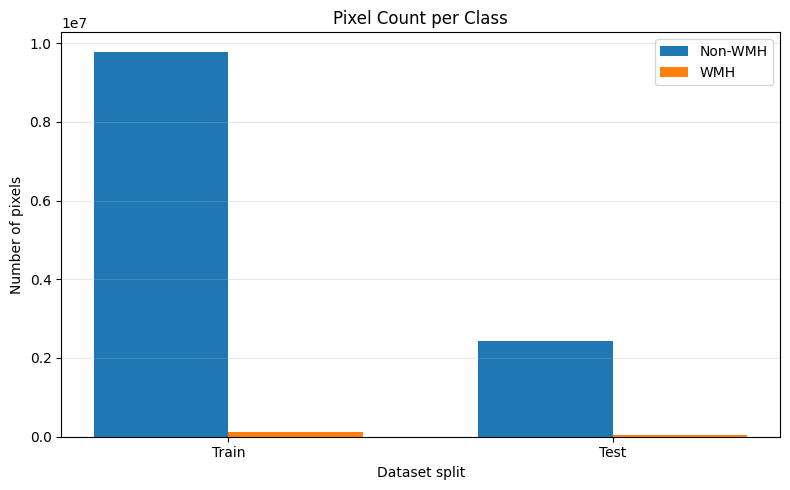

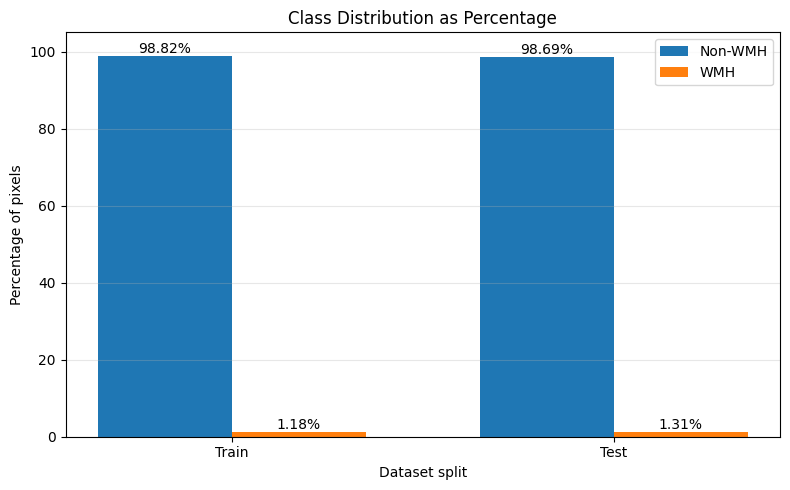

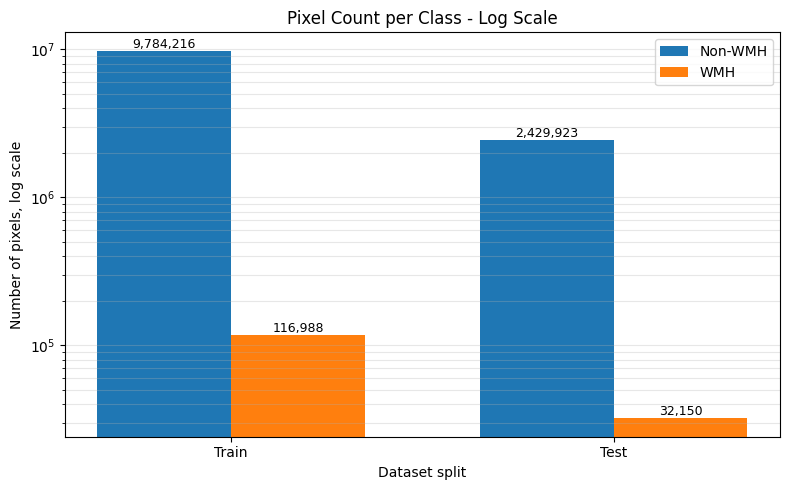

/tmp/ipykernel_2372/1999515141.py:151: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=["Train", "Test"], showfliers=True)


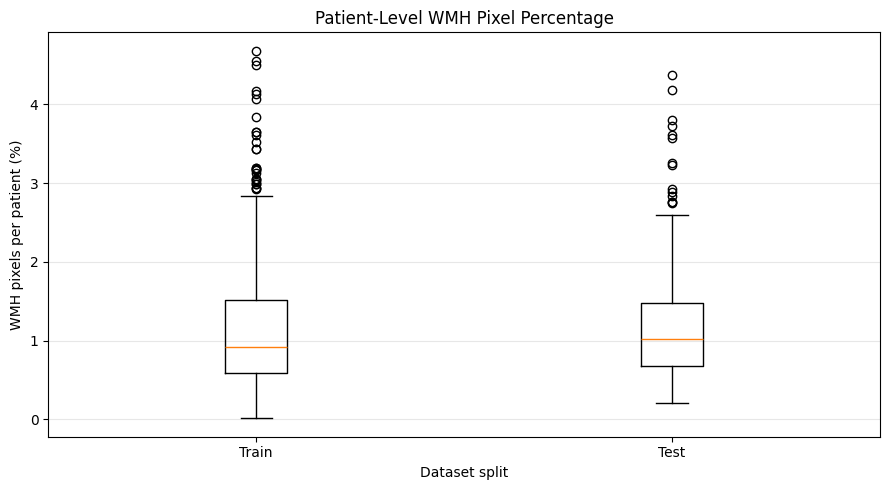

In [28]:
def summarize_class_distribution(df, split_name):
    counts = df["WMH"].value_counts().sort_index()
    perc = df["WMH"].value_counts(normalize=True).sort_index() * 100

    summary = pd.DataFrame({
        "split": split_name,
        "class": counts.index,
        "count": counts.values,
        "percentage": perc.values
    })

    summary["class_name"] = summary["class"].map({
        0: "Non-WMH",
        1: "WMH"
    })

    return summary


train_summary = summarize_class_distribution(train_df, "Train")
test_summary  = summarize_class_distribution(test_df, "Test")

class_summary = pd.concat([train_summary, test_summary], ignore_index=True)

display(class_summary)



# 1. Absolute pixel counts

fig, ax = plt.subplots(figsize=(8, 5))

splits = class_summary["split"].unique()
class_names = ["Non-WMH", "WMH"]

x = np.arange(len(splits))
width = 0.35

for i, class_name in enumerate(class_names):
    values = class_summary[class_summary["class_name"] == class_name]["count"].values
    ax.bar(x + (i - 0.5) * width, values, width, label=class_name)

ax.set_title("Pixel Count per Class")
ax.set_xlabel("Dataset split")
ax.set_ylabel("Number of pixels")
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# 2. Percentage distribution

fig, ax = plt.subplots(figsize=(8, 5))

for i, class_name in enumerate(class_names):
    values = class_summary[class_summary["class_name"] == class_name]["percentage"].values
    bars = ax.bar(x + (i - 0.5) * width, values, width, label=class_name)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

ax.set_title("Class Distribution as Percentage")
ax.set_xlabel("Dataset split")
ax.set_ylabel("Percentage of pixels")
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()



# 3. Log-scale pixel counts (used because here the minority class is very small)


fig, ax = plt.subplots(figsize=(8, 5))

for i, class_name in enumerate(class_names):
    values = class_summary[class_summary["class_name"] == class_name]["count"].values
    bars = ax.bar(x + (i - 0.5) * width, values, width, label=class_name)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_yscale("log")
ax.set_title("Pixel Count per Class - Log Scale")
ax.set_xlabel("Dataset split")
ax.set_ylabel("Number of pixels, log scale")
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.legend()
ax.grid(axis="y", alpha=0.3, which="both")

plt.tight_layout()
plt.show()


# 4. Percentage of WMH pixels per patient


train_patient_load = (
    train_df
    .groupby("patient_id")["WMH"]
    .mean()
    .mul(100)
    .reset_index(name="WMH_percentage")
)
train_patient_load["split"] = "Train"

test_patient_load = (
    test_df
    .groupby("patient_id")["WMH"]
    .mean()
    .mul(100)
    .reset_index(name="WMH_percentage")
)
test_patient_load["split"] = "Test"

patient_load = pd.concat([train_patient_load, test_patient_load], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 5))

data_to_plot = [
    patient_load[patient_load["split"] == "Train"]["WMH_percentage"],
    patient_load[patient_load["split"] == "Test"]["WMH_percentage"]
]

ax.boxplot(data_to_plot, labels=["Train", "Test"], showfliers=True)

ax.set_title("Patient-Level WMH Pixel Percentage")
ax.set_xlabel("Dataset split")
ax.set_ylabel("WMH pixels per patient (%)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()




define intput and output feature

In [29]:
feature_cols = [
    "mean",
    "std",
    "skew",
    "kurtosis",
    "localZ",
    "topHat",
    "prior",
    "regionalPrior",
    "distance",
]

X_train = train_df[feature_cols].values.astype("float32")
y_train = train_df["WMH"].values.astype("int32")

X_test = test_df[feature_cols].values.astype("float32")
y_test = test_df["WMH"].values.astype("int32")

In [30]:
# Define the two possible classes in the binary segmentation problem:
# 0 = non-WMH pixel
# 1 = WMH pixel
classes = np.array([0, 1])

# Compute automatic class weights using the "balanced" strategy.
# This gives higher weight to the minority class and lower weight to the majority class.
#
# Formula used by sklearn:
# weight_class = total_number_of_samples / (number_of_classes * number_of_samples_in_that_class)
#
# Since WMH pixels are rare, the weight for class 1 will usually be much larger
# than the weight for class 0.
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Convert the weights array into the dictionary format expected by Keras/TensorFlow.
# Example:
# {
#     0: weight_for_non_WMH,
#     1: weight_for_WMH
# }
class_weight = {
    0: weights[0],
    1: weights[1]
}

# final class weights that will be passed to model.fit(..., class_weight=class_weight)
print("Class weights:", class_weight)

Class weights: {0: np.float64(0.5059784044015382), 1: np.float64(42.317177830204805)}


In [31]:
# seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 3 - Model definition

In [32]:
def build_model(n_features):
    model = models.Sequential([
        layers.Input(shape=(n_features,)),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        layers.Dropout(0.30),

        layers.Dense(
            32,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        layers.Dropout(0.30),

        layers.Dense(
            16,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-4)
        ),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [33]:
def dice_score(y_true, y_pred, eps=1e-8):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)

    intersection = np.logical_and(y_true, y_pred).sum()
    total = y_true.sum() + y_pred.sum()

    return (2 * intersection + eps) / (total + eps)


def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    dice = dice_score(y_true, y_pred)
    sensitivity = tp / (tp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    specificity = tn / (tn + fp + 1e-8)

    return {
        "dice": dice,
        "sensitivity": sensitivity,
        "precision": precision,
        "specificity": specificity,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

## 4 - 5 fold cross validation

In this section, the neural network is evaluated using **GroupKFold cross-validation**.  
The groups are defined by `patient_id`, so all pixels belonging to the same patient are kept entirely in either the training fold or the validation fold. This avoids data leakage, because pixels from the same MRI slice/patient are highly correlated and should not appear in both training and validation at the same time.

For each fold, the code:

1. splits the training dataframe into fold-specific training and validation patients;
2. extracts the feature matrix `X`, the binary WMH labels `y`, and the patient groups;
3. computes class weights only on the fold training labels, so that the rare WMH class receives a larger penalty during training;
4. trains a new neural network from scratch;
5. predicts WMH probabilities on the validation fold;
6. thresholds the probabilities at `0.5`;
7. computes segmentation metrics such as Dice, sensitivity, precision, specificity, and the confusion matrix.

This validation strategy gives a more realistic estimate of generalization performance, because the model is tested on patients that were not seen during training.

In [35]:
gkf = GroupKFold(n_splits=5)

fold_results = []
histories = []

threshold = 0.5


X = train_df[feature_cols].values.astype("float32")
y = train_df["WMH"].values.astype("int32")
groups = train_df["patient_id"].values

n_features = X.shape[1]

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), start=1):

    print(f"\n================ FOLD {fold} / 5 ================")

    X_fold_train = X[train_idx]
    y_fold_train = y[train_idx]

    X_fold_val = X[val_idx]
    y_fold_val = y[val_idx]

    train_patients_fold = np.unique(groups[train_idx])
    val_patients_fold = np.unique(groups[val_idx])

    print("Training patients:", len(train_patients_fold))
    print("Validation patients:", len(val_patients_fold))
    print("Training pixels:", X_fold_train.shape[0])
    print("Validation pixels:", X_fold_val.shape[0])
    print("Training WMH pixels:", y_fold_train.sum())
    print("Validation WMH pixels:", y_fold_val.sum())

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_fold_train
    )

    fold_class_weight = {
        0: weights[0],
        1: weights[1]
    }

    print("Fold class weights:", fold_class_weight)

    tf.keras.backend.clear_session()
    model = build_model(n_features)

    history = model.fit(
        X_fold_train,
        y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=10,
        batch_size=4096,
        class_weight=fold_class_weight,
        shuffle=True,
        verbose=1
    )

    histories.append(history)

    y_val_prob = model.predict(X_fold_val, batch_size=4096).ravel()
    y_val_pred = (y_val_prob >= threshold).astype("int32")

    metrics = compute_metrics(y_fold_val, y_val_pred)
    metrics["fold"] = fold
    fold_results.append(metrics)

    print(f"\nFold {fold} results at threshold {threshold}:")
    print(f"Dice:        {metrics['dice']:.4f}")
    print(f"Sensitivity: {metrics['sensitivity']:.4f}")
    print(f"Precision:   {metrics['precision']:.4f}")
    print(f"Specificity: {metrics['specificity']:.4f}")
    print("Confusion matrix:")
    print(np.array([[metrics["tn"], metrics["fp"]],
                    [metrics["fn"], metrics["tp"]]]))


================ FOLD 1 / 5 ================
Training patients: 391
Validation patients: 98
Training pixels: 7916927
Validation pixels: 1984277
Training WMH pixels: 93760
Validation WMH pixels: 23228
Fold class weights: {0: np.float64(0.505992458041609), 1: np.float64(42.219107295221846)}
Epoch 1/10
1933/1933 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.9323 - auc: 0.9832 - loss: 0.1724 - precision: 0.1429 - recall: 0.9443 - val_accuracy: 0.9558 - val_auc: 0.9921 - val_loss: 0.1279 - val_precision: 0.2053 - val_recall: 0.9668
Epoch 2/10
1933/1933 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.9578 - auc: 0.9922 - loss: 0.1126 - precision: 0.2153 - recall: 0.9708 - val_accuracy: 0.9640 - val_auc: 0.9938 - val_loss: 0.1092 - val_precision: 0.2414 - val_recall: 0.9695
Epoch 3/10
1933/1933 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9620 - auc: 0.9935 - loss: 0.1027 - precision: 0.2340 - recall: 0.9733 - val_accuracy: 0.9643 - val_auc: 0.9944 - val_loss: 0.1057 - val_precision:

The results collected from the 5 validation folds are converted into a Pandas DataFrame so they can be inspected more clearly.

For each fold, the table reports the main segmentation metrics:

- **Dice**: overlap between predicted WMH pixels and true WMH pixels;
- **Sensitivity**: fraction of true WMH pixels correctly detected;
- **Precision**: fraction of predicted WMH pixels that are actually WMH;
- **Specificity**: fraction of non-WMH pixels correctly classified;
- **TN, FP, FN, TP**: confusion matrix components.

After printing the fold-by-fold results, the code computes the **mean** and **standard deviation** across folds.  
The mean gives the average validation performance, while the standard deviation shows how stable the model is across different patient splits.

This is useful because, in an imbalanced WMH segmentation task, a single validation split may be misleading. Cross-validation gives a more reliable estimate of how well the model generalizes to unseen patients.

In [36]:
cv_results = pd.DataFrame(fold_results)

print(cv_results[[
    "fold",
    "dice",
    "sensitivity",
    "precision",
    "specificity",
    "tn",
    "fp",
    "fn",
    "tp"
]])

print("\nMean CV results:")
print(cv_results[["dice", "sensitivity", "precision", "specificity"]].mean())

print("\nStd CV results:")
print(cv_results[["dice", "sensitivity", "precision", "specificity"]].std())

   fold      dice  sensitivity  precision  specificity       tn     fp   fn  \
0     1  0.400265     0.973954   0.251893     0.965738  1893860  67189  605   
1     2  0.512185     0.962721   0.348904     0.977375  1915348  44337  920   
2     3  0.433109     0.973141   0.278538     0.972003  1889692  54430  580   
3     4  0.466067     0.978409   0.305889     0.973354  1908145  52236  508   
4     5  0.424730     0.975917   0.271429     0.967962  1896217  62762  577   

      tp  
0  22623  
1  23759  
2  21014  
3  23020  
4  23382  

Mean CV results:
dice           0.447271
sensitivity    0.972828
precision      0.291331
specificity    0.971287
dtype: float64

Std CV results:
dice           0.043259
sensitivity    0.006004
precision      0.037556
specificity    0.004574
dtype: float64


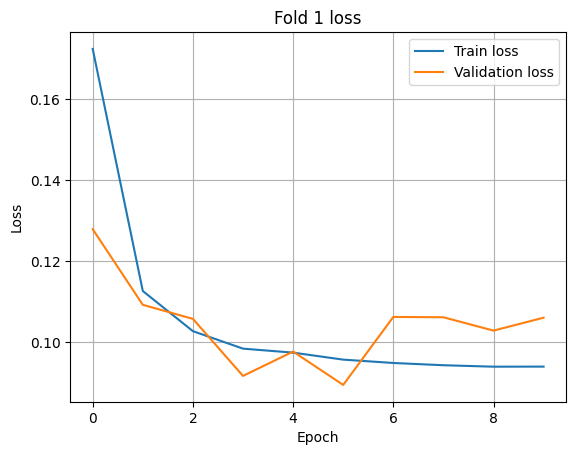

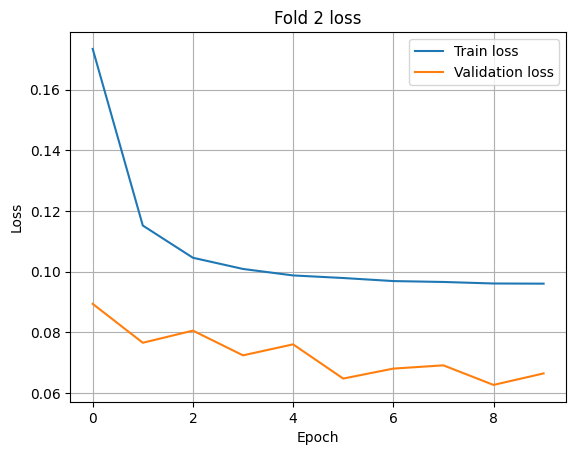

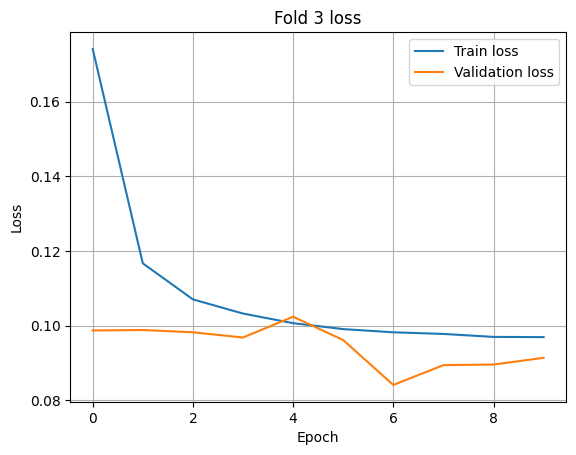

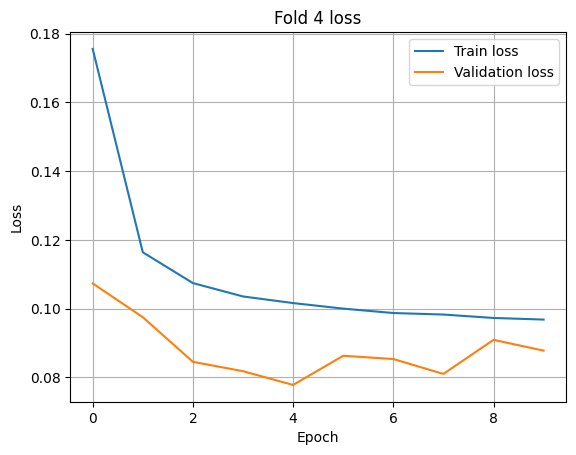

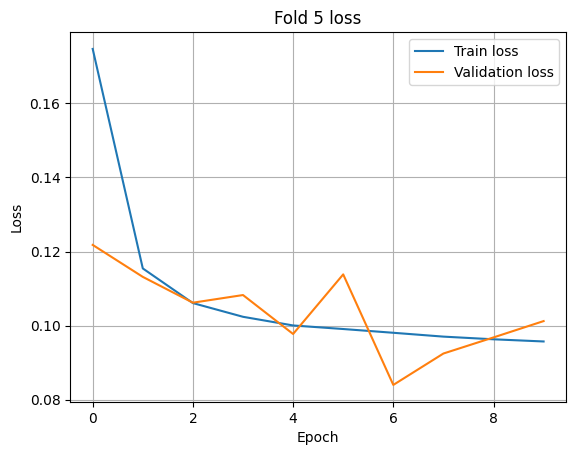

In [37]:
for i, history in enumerate(histories, start=1):
    plt.figure()
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {i} loss")
    plt.legend()
    plt.grid(True)
    plt.show()

The learning curves look generally stable and suggest that the neural network is not strongly overfitting. In all folds, the training loss decreases rapidly during the first epochs and then slowly converges, while the validation loss remains in the same range or even lower than the training loss. The validation curves show some fluctuations, especially in folds 1, 3, and 4, but there is no clear progressive divergence between training and validation loss, so the model seems to generalize reasonably well across patient splits.

### Final model training on the full training set

After estimating the model performance with patient-level cross-validation, the final neural network is trained again using the entire training set.

In this step, the code:

1. extracts the final training feature matrix `X_train_final` and labels `y_train_final`;
2. extracts the independent test feature matrix `X_test_final` and labels `y_test_final`;
3. computes class weights only from the training labels, so the rare WMH class receives a larger penalty during optimization;
4. clears the previous TensorFlow/Keras session;
5. builds a new neural network with the same architecture used during cross-validation;
6. trains the final model on all available training patients.

The test set is not used during training. It is kept separate and will be used only afterward to evaluate the final generalization performance on unseen patients.

In [38]:
X_train_final = train_df[feature_cols].values.astype("float32")
y_train_final = train_df["WMH"].values.astype("int32")

X_test_final = test_df[feature_cols].values.astype("float32")
y_test_final = test_df["WMH"].values.astype("int32")

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train_final
)

final_class_weight = {
    0: weights[0],
    1: weights[1]
}

tf.keras.backend.clear_session()
final_model = build_model(n_features)

final_history = final_model.fit(
    X_train_final,
    y_train_final,
    epochs=30,
    batch_size=4096,
    class_weight=final_class_weight,
    shuffle=True,
    verbose=1
)

# Save the final trained model weights
w_path = "/content/drive/MyDrive/Computational Intelligence/final_model_weights.weights.h5"
final_model.save_weights(w_path)


Epoch 1/30
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - accuracy: 0.9387 - auc: 0.9847 - loss: 0.1644 - precision: 0.1554 - recall: 0.9446
Epoch 2/30
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9580 - auc: 0.9924 - loss: 0.1123 - precision: 0.2159 - recall: 0.9699
Epoch 3/30
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9623 - auc: 0.9935 - loss: 0.1038 - precision: 0.2352 - recall: 0.9721
Epoch 4/30
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - accuracy: 0.9635 - auc: 0.9938 - loss: 0.1002 - precision: 0.2413 - recall: 0.9736
Epoch 5/30
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9642 - auc: 0.9940 - loss: 0.0987 - precision: 0.2448 - recall: 0.9734
Epoch 6/30
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - accuracy: 0.9644 - auc: 0.9940 - loss: 0.0976 - precision: 0.2461 - recall: 0.9739
Epoch 7/30
2418/2418 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9647 - auc: 0.9941 - loss: 0.0970 - precision: 0.2473 - recall: 0.9737
Epoch 8/30
24

### Final evaluation on the independent test set

In this cell, the final trained neural network is evaluated on the independent test set, which was not used during training or cross-validation.

The model first predicts a WMH probability for every test pixel. These probabilities are then converted into binary labels using a fixed threshold of `0.5`:

```text
probability >= 0.5  →  WMH
probability < 0.5   →  non-WMH

In [41]:
# Rebuild the same architecture
loaded_model = build_model(n_features)

# Load the saved weights
loaded_model.load_weights("/content/drive/MyDrive/Computational Intelligence/final_model_weights.weights.h5")

# Use the loaded model on the test set
y_test_prob = loaded_model.predict(X_test_final, batch_size=4096).ravel()
y_test_pred = (y_test_prob >= 0.5).astype("int32")

test_metrics = compute_metrics(y_test_final, y_test_pred)

print("\nTEST RESULTS USING LOADED WEIGHTS")
print(f"Dice:        {test_metrics['dice']:.4f}")
print(f"Sensitivity: {test_metrics['sensitivity']:.4f}")
print(f"Precision:   {test_metrics['precision']:.4f}")
print(f"Specificity: {test_metrics['specificity']:.4f}")
print("Confusion matrix:")
print(np.array([[test_metrics["tn"], test_metrics["fp"]],
                [test_metrics["fn"], test_metrics["tp"]]]))

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


602/602 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step

TEST RESULTS USING LOADED WEIGHTS
Dice:        0.4971
Sensitivity: 0.9497
Precision:   0.3367
Specificity: 0.9752
Confusion matrix:
[[2369761   60162]
 [   1616   30534]]
